# GAN and VAE Anomaly Detection for Early Warning Systems

This notebook implements two deep novelty-detection directions for the real BC4 Early Warning System dataset:

- **GAN-based anomaly detection**: learn normal market realism through a discriminator and generator.
- **VAE-based anomaly detection**: learn a probabilistic latent representation of normal market behavior and detect observations with high reconstruction error.

The notebook uses the **real BC4 market dataset** (`Dataset4_EWS.xlsx`) rather than synthetic Gaussian data. The modeling logic remains aligned with the existing MVG and Autoencoder models:

1. Transform the real market series into stationary features.
2. Train on **normal observations only**.
3. Score each cross-validation and test observation.
4. Choose a threshold `epsilon` on the cross-validation set.
5. Evaluate on the held-out test set with precision, recall, F1, ROC-AUC, confusion matrix, and score plots.

GAN flow:

```text
Noise vector z
      ↓
Generator
      ↓
Synthetic normal market sample
      ↓
Discriminator
      ↓
Probability of being real normal data
```

Implemented anomaly scores:

- **GAN discriminator realism score**: low `D(x)` means the point does not look like real normal data.
- **GAN reconstruction score**: find a latent vector `z*` such that `G(z*)` reconstructs `x`, then use the reconstruction error.
- **VAE reconstruction score**: encode and decode `x`; high reconstruction error means the point is hard to explain under learned normality.


In [28]:
# Setup: imports and reproducibility
from __future__ import annotations

import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.metrics import (
    auc,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
)
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = [10, 6]


print(f"Using device: {device}")

Using device: cpu


## 1. Load and prepare the real BC4 market dataset

We use the same real dataset and stationarity logic as the original Early Warning System notebook:

- log-differences for indices, currencies, commodities, credit/bond total-return series, and volatility-like market variables
- first differences for interest rates
- unchanged Bloomberg Economic US Surprise Index, because it is already treated as stationary

The train/CV/test split follows the anomaly-detection setup from the original notebook:

- training set: normal observations only
- cross-validation set: normal observations plus half of the anomalies
- test set: remaining normal observations plus the remaining anomalies

This means the GAN is trained directly on real normal market observations, not on synthetic data.

Dataset path: Dataset4_EWS.xlsx
Stationary feature matrix: 1110 observations x 42 features
Total anomalies after stationarity/dropna: 237 (21.35%)
Training set: 698 normal observations
Cross-validation set: 205 observations (87 normal, 118 anomalies)
Test set: 207 observations (88 normal, 119 anomalies)


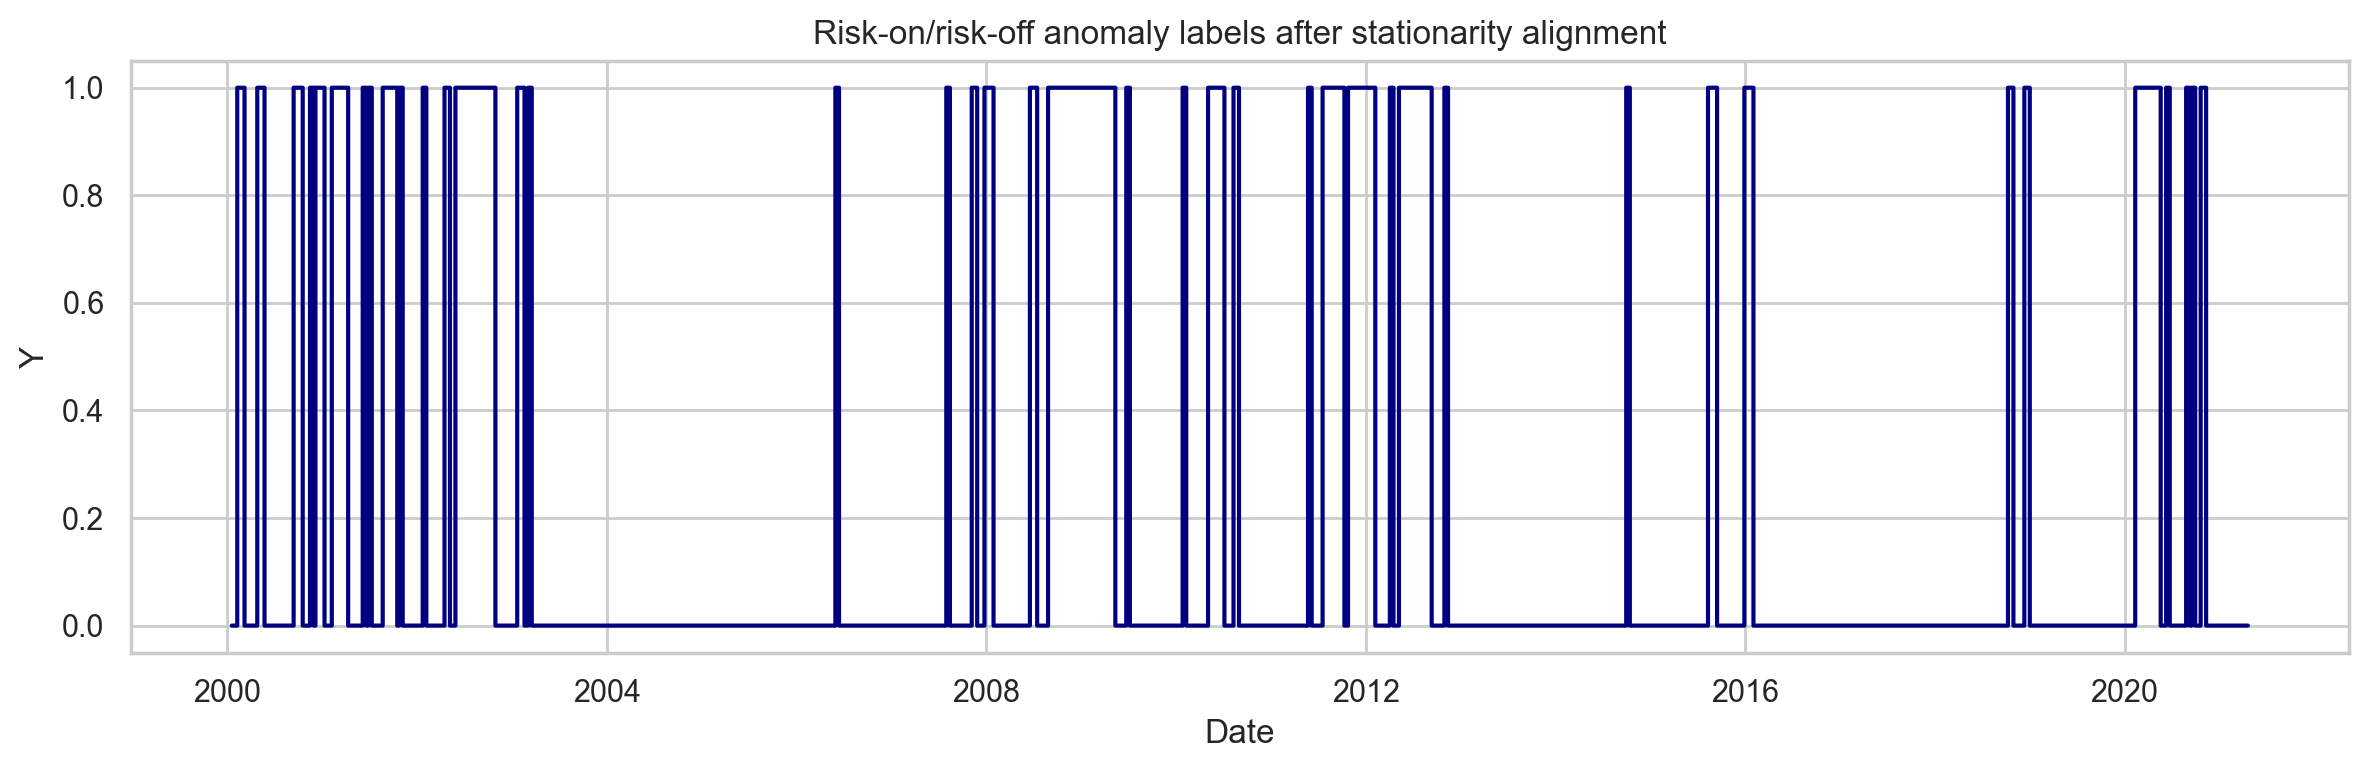

In [29]:
# Load the real BC4 EWS dataset and reproduce the original stationarity/split pipeline.
dataset_path = Path("BC4/Dataset4_EWS.xlsx")
if not dataset_path.exists():
    dataset_path = Path("Dataset4_EWS.xlsx")
if not dataset_path.exists():
    raise FileNotFoundError("Could not find Dataset4_EWS.xlsx in BC4/ or the current directory.")

data_df = pd.read_excel(dataset_path, sheet_name="Markets")
metadata_df = pd.read_excel(dataset_path, sheet_name="Metadata")

# Date and label columns follow the original notebook conventions.
date_col = "Date" if "Date" in data_df.columns else data_df.columns[0]
y_col = "Y" if "Y" in data_df.columns else None
if y_col is None:
    raise ValueError("Expected an anomaly label column named 'Y' in the Markets sheet.")

data_df[date_col] = pd.to_datetime(data_df[date_col], dayfirst=True)
data_df = data_df.set_index(date_col).sort_index()

X_df = data_df.drop(columns=[y_col])
y_raw = data_df[y_col].astype(int).values

indices_currencies = [col for col in X_df.columns if col in [
    "XAUBGNL", "BDIY", "CRY", "Cl1", "DXY", "EMUSTRUU", "GBP", "JPY", "LF94TRUU",
    "LF98TRUU", "LG30TRUU", "LMBITR", "LP01TREU", "LUACTRUU", "LUMSTRUU",
    "MXBR", "MXCN", "MXEU", "MXIN", "MXJP", "MXRU", "MXUS", "VIX"
]]

interest_rates = [col for col in X_df.columns if col in [
    "EONIA", "GTDEM10Y", "GTDEM2Y", "GTDEM30Y", "GTGBP20Y", "GTGBP2Y", "GTGBP30Y",
    "GTITL10YR", "GTITL2YR", "GTITL30YR", "GTJPY10YR", "GTJPY2YR", "GTJPY30YR",
    "US0001M", "USGG3M", "USGG2YR", "GT10", "USGG30YR"
]]

stationary_df = pd.DataFrame(index=X_df.index[1:])

# Log-differences for positive market level / total return series.
for col in indices_currencies:
    stationary_df[col] = np.diff(np.log(X_df[col].astype(float)))

# First differences for rates.
for col in interest_rates:
    stationary_df[col] = np.diff(X_df[col].astype(float))

# Keep the surprise index as-is, aligned after the first row.
if "ECSURPUS" in X_df.columns:
    stationary_df["ECSURPUS"] = X_df["ECSURPUS"].astype(float).values[1:]

# Align labels to transformed features and drop rows with missing/non-finite values.
y_stationary = y_raw[1:]
stationary_df = stationary_df.replace([np.inf, -np.inf], np.nan)
valid_mask = stationary_df.notna().all(axis=1)
stationary_df = stationary_df.loc[valid_mask]
y_stationary = y_stationary[valid_mask.to_numpy()].astype(int)
feature_names = stationary_df.columns.to_list()

X = stationary_df.values
y = y_stationary

# Reshuffle before splitting, as in the real-data section of the original notebook.
X_shuffled, y_shuffled = shuffle(X, y, random_state=SEED)
X_normal = X_shuffled[y_shuffled == 0]
X_anomaly = X_shuffled[y_shuffled == 1]

n_normal = X_normal.shape[0]
n_anomaly = X_anomaly.shape[0]
if n_normal == 0 or n_anomaly < 2:
    raise ValueError("Need normal observations and at least two anomalies for the train/CV/test split.")

train_size = int(0.8 * n_normal)
cv_normal_size = int(0.1 * n_normal)
cv_anomaly_size = max(1, int(0.5 * n_anomaly))

X_train_raw = X_normal[:train_size]
X_cv_normal = X_normal[train_size:train_size + cv_normal_size]
X_cv_anomaly = X_anomaly[:cv_anomaly_size]
X_cross_val_raw = np.vstack([X_cv_normal, X_cv_anomaly])
y_cross_val = np.hstack([np.zeros(len(X_cv_normal)), np.ones(len(X_cv_anomaly))]).astype(int)

X_test_normal = X_normal[train_size + cv_normal_size:]
X_test_anomaly = X_anomaly[cv_anomaly_size:]
X_test_raw = np.vstack([X_test_normal, X_test_anomaly])
y_test = np.hstack([np.zeros(len(X_test_normal)), np.ones(len(X_test_anomaly))]).astype(int)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_cross_val = scaler.transform(X_cross_val_raw)
X_test = scaler.transform(X_test_raw)

print(f"Dataset path: {dataset_path}")
print(f"Stationary feature matrix: {stationary_df.shape[0]} observations x {stationary_df.shape[1]} features")
print(f"Total anomalies after stationarity/dropna: {int(y.sum())} ({y.mean() * 100:.2f}%)")
print(f"Training set: {X_train.shape[0]} normal observations")
print(f"Cross-validation set: {X_cross_val.shape[0]} observations ({len(X_cv_normal)} normal, {len(X_cv_anomaly)} anomalies)")
print(f"Test set: {X_test.shape[0]} observations ({len(X_test_normal)} normal, {len(X_test_anomaly)} anomalies)")

plt.figure(figsize=(12, 4))
plt.plot(stationary_df.index, y_stationary, drawstyle="steps-post", color="navy")
plt.title("Risk-on/risk-off anomaly labels after stationarity alignment")
plt.xlabel("Date")
plt.ylabel("Y")
plt.tight_layout()
plt.show()

## 2. Define the GAN

The discriminator returns a **logit**, not a probability. During training we use `BCEWithLogitsLoss`, which is numerically more stable than applying a sigmoid first. During scoring we convert logits to probabilities with `torch.sigmoid`.

The generator maps a latent noise vector `z` into a synthetic normal market sample.

In [30]:
# GAN architecture
input_dim = X_train.shape[1]
latent_dim = min(16, max(4, input_dim // 4))
hidden_dim = min(128, max(32, input_dim * 2))
batch_size = min(128, max(16, len(X_train) // 10))

train_tensor = torch.tensor(X_train, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(train_tensor), batch_size=batch_size, shuffle=True)

class Generator(nn.Module):
    def __init__(self, latent_dim: int, output_dim: int, hidden_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(hidden_dim),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

G = Generator(latent_dim, input_dim, hidden_dim).to(device)
D = Discriminator(input_dim, hidden_dim).to(device)

criterion = nn.BCEWithLogitsLoss()
g_optimizer = optim.Adam(G.parameters(), lr=1e-3, betas=(0.5, 0.999))
d_optimizer = optim.Adam(D.parameters(), lr=1e-3, betas=(0.5, 0.999))

print(f"Input dimension: {input_dim}")
print(f"Latent dimension: {latent_dim}")
print(f"Hidden dimension: {hidden_dim}")
print(f"Batch size: {batch_size}")
G, D

Input dimension: 42
Latent dimension: 10
Hidden dimension: 84
Batch size: 69


(Generator(
   (net): Sequential(
     (0): Linear(in_features=10, out_features=84, bias=True)
     (1): LeakyReLU(negative_slope=0.2)
     (2): BatchNorm1d(84, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (3): Linear(in_features=84, out_features=84, bias=True)
     (4): LeakyReLU(negative_slope=0.2)
     (5): BatchNorm1d(84, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (6): Linear(in_features=84, out_features=42, bias=True)
   )
 ),
 Discriminator(
   (net): Sequential(
     (0): Linear(in_features=42, out_features=84, bias=True)
     (1): LeakyReLU(negative_slope=0.2)
     (2): Dropout(p=0.2, inplace=False)
     (3): Linear(in_features=84, out_features=84, bias=True)
     (4): LeakyReLU(negative_slope=0.2)
     (5): Dropout(p=0.2, inplace=False)
     (6): Linear(in_features=84, out_features=1, bias=True)
   )
 ))

## 3. Train on normal market samples only

The discriminator sees:

- real normal observations from the training set
- generated normal-like observations from the generator

The generator learns to produce samples that the discriminator classifies as real normal data.

Epoch 001 | D loss=1.3687 | G loss=0.6253
Epoch 050 | D loss=1.3913 | G loss=0.7237
Epoch 100 | D loss=1.3895 | G loss=0.6880
Epoch 150 | D loss=1.3751 | G loss=0.6915
Epoch 200 | D loss=1.3804 | G loss=0.7098
Epoch 250 | D loss=1.3520 | G loss=0.6839
Epoch 300 | D loss=1.3714 | G loss=0.7200


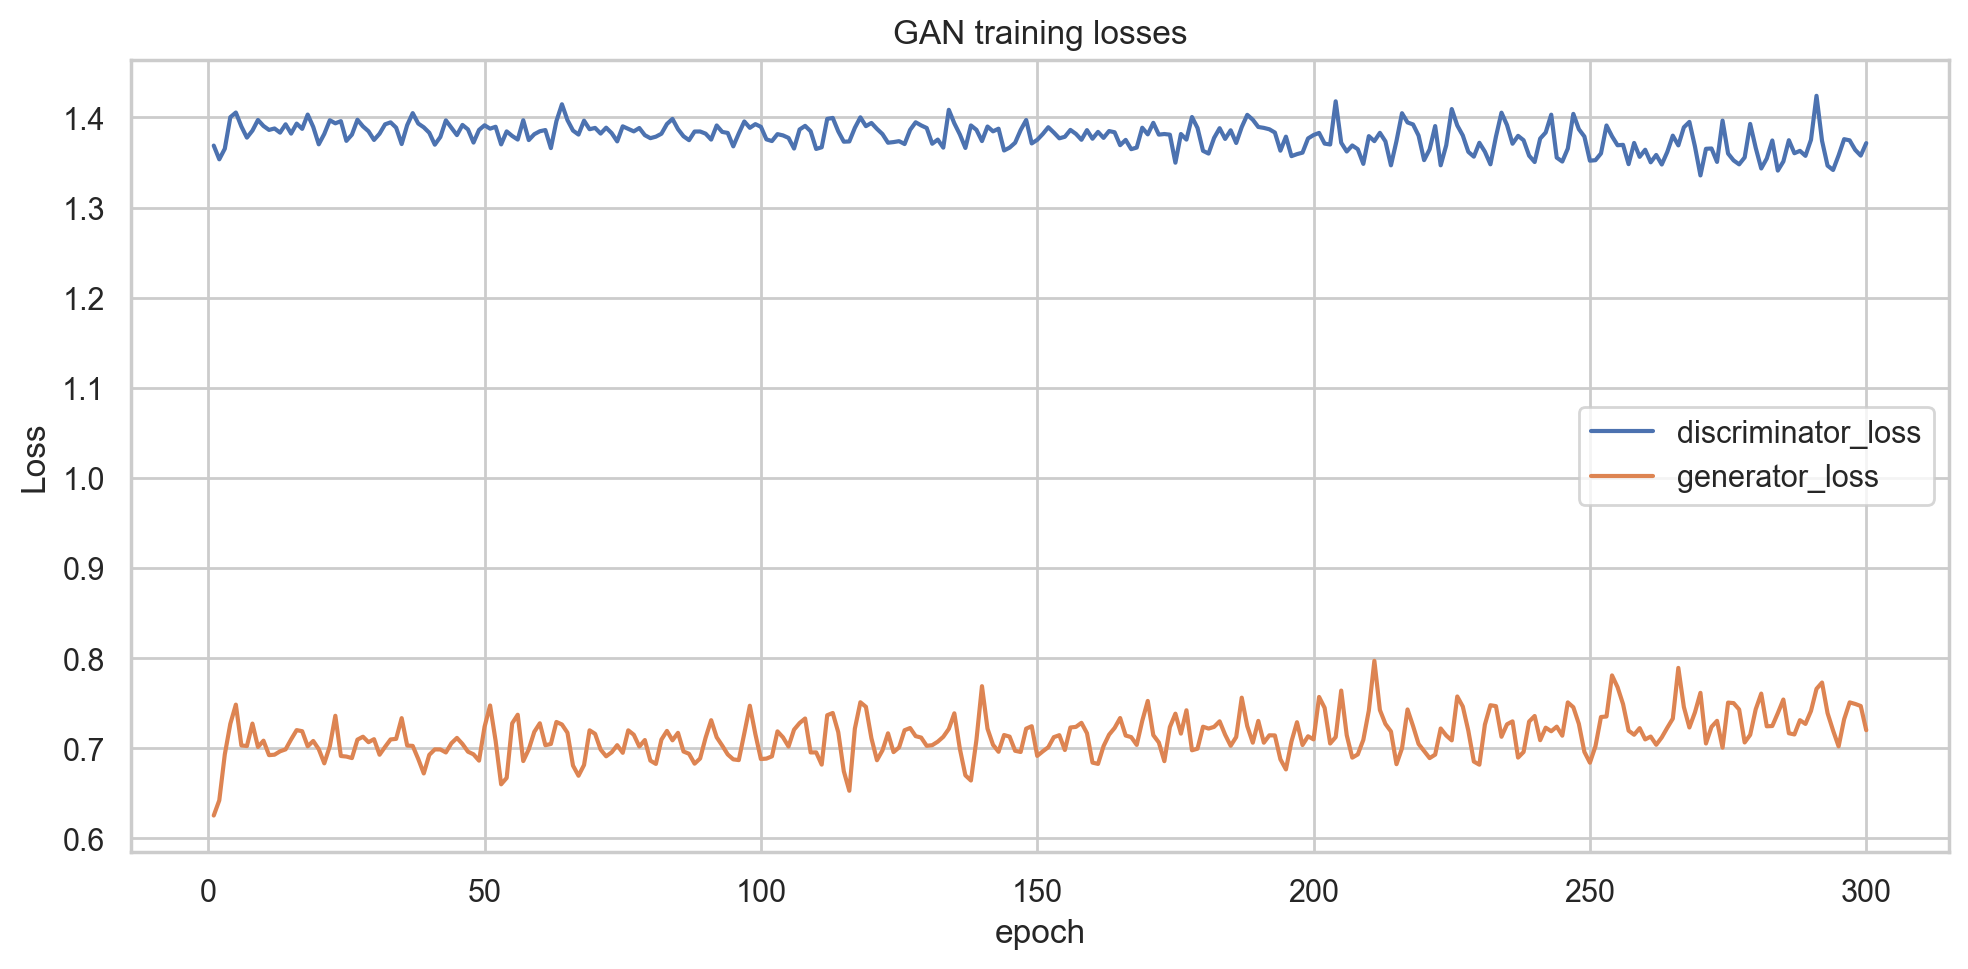

In [31]:
def train_gan(generator, discriminator, loader, epochs=300, print_every=50):
    history = []
    generator.train()
    discriminator.train()

    for epoch in range(1, epochs + 1):
        epoch_d_loss = 0.0
        epoch_g_loss = 0.0

        for (real_batch,) in loader:
            real_batch = real_batch.to(device)
            current_batch_size = real_batch.size(0)

            real_labels = torch.ones(current_batch_size, device=device)
            fake_labels = torch.zeros(current_batch_size, device=device)

            # 1. Train discriminator: real normal samples should be real, generated samples should be fake.
            z = torch.randn(current_batch_size, latent_dim, device=device)
            fake_batch = generator(z).detach()

            d_optimizer.zero_grad()
            real_logits = discriminator(real_batch)
            fake_logits = discriminator(fake_batch)
            d_loss = criterion(real_logits, real_labels) + criterion(fake_logits, fake_labels)
            d_loss.backward()
            d_optimizer.step()

            # 2. Train generator: generated samples should look real to the discriminator.
            z = torch.randn(current_batch_size, latent_dim, device=device)
            g_optimizer.zero_grad()
            generated_batch = generator(z)
            generated_logits = discriminator(generated_batch)
            g_loss = criterion(generated_logits, real_labels)
            g_loss.backward()
            g_optimizer.step()

            epoch_d_loss += d_loss.item()
            epoch_g_loss += g_loss.item()

        avg_d_loss = epoch_d_loss / len(loader)
        avg_g_loss = epoch_g_loss / len(loader)
        history.append({"epoch": epoch, "discriminator_loss": avg_d_loss, "generator_loss": avg_g_loss})

        if epoch == 1 or epoch % print_every == 0:
            print(f"Epoch {epoch:03d} | D loss={avg_d_loss:.4f} | G loss={avg_g_loss:.4f}")

    return pd.DataFrame(history)

history = train_gan(G, D, train_loader, epochs=300, print_every=50)

history.plot(x="epoch", y=["discriminator_loss", "generator_loss"], figsize=(10, 5))
plt.title("GAN training losses")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

## 4. Score anomalies with discriminator realism

The discriminator realism score is:

$$
D_{prob}(x) = P(\text{real normal data} \mid x)
$$

A point is anomalous when this probability is too low:

$$
\text{Anomaly} \Longleftrightarrow D_{prob}(x) < \varepsilon
$$

To keep the evaluation logic identical to the original notebook, we select `epsilon` on the cross-validation set by maximizing F1.

In [32]:
def discriminator_realism_score(discriminator, X):
    discriminator.eval()
    X_tensor = torch.tensor(X, dtype=torch.float32, device=device)
    with torch.no_grad():
        logits = discriminator(X_tensor)
        probabilities = torch.sigmoid(logits).cpu().numpy()
    return probabilities

def choose_low_score_threshold(y_true, normality_score, n_grid=1000):
    """Low score means more anomalous. Predict anomaly when score < epsilon."""
    thresholds = np.linspace(normality_score.min(), normality_score.max(), n_grid)
    best = {"epsilon": thresholds[0], "f1": -1.0, "precision": 0.0, "recall": 0.0}

    for epsilon in thresholds:
        pred = (normality_score < epsilon).astype(int)
        precision = precision_score(y_true, pred, zero_division=0)
        recall = recall_score(y_true, pred, zero_division=0)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > best["f1"]:
            best = {"epsilon": epsilon, "f1": f1, "precision": precision, "recall": recall}

    return best

cv_realism = discriminator_realism_score(D, X_cross_val)
test_realism = discriminator_realism_score(D, X_test)

realism_threshold = choose_low_score_threshold(y_cross_val, cv_realism)
y_pred_realism = (test_realism < realism_threshold["epsilon"]).astype(int)

realism_threshold

{'epsilon': np.float32(0.94650984),
 'f1': 0.7267080745341615,
 'precision': 0.5735294117647058,
 'recall': 0.9915254237288136}

## 5. Score anomalies with GAN reconstruction

A plain GAN has no encoder, so we cannot directly map an input `x` into a latent vector. For reconstruction scoring, we search for the latent vector `z*` whose generated sample is closest to `x`:

$$
z^* = \arg\min_z \|x - G(z)\|^2
$$

Then the anomaly score is the reconstruction error:

$$
\text{Anomaly} \Longleftrightarrow \|x - G(z^*)\|^2 > \varepsilon
$$

This is slower than discriminator scoring, but it is closer to the Autoencoder logic used in the original notebook.

In [33]:
def gan_reconstruction_error(generator, X, latent_dim, steps=250, lr=0.05, batch_size=128):
    generator.eval()
    errors = []

    for start in range(0, len(X), batch_size):
        batch_np = X[start:start + batch_size]
        x = torch.tensor(batch_np, dtype=torch.float32, device=device)
        z = torch.randn(x.size(0), latent_dim, device=device, requires_grad=True)
        z_optimizer = optim.Adam([z], lr=lr)

        for _ in range(steps):
            z_optimizer.zero_grad()
            reconstructed = generator(z)
            loss = ((reconstructed - x) ** 2).mean()
            loss.backward()
            z_optimizer.step()

        with torch.no_grad():
            reconstructed = generator(z)
            batch_errors = ((reconstructed - x) ** 2).mean(dim=1).cpu().numpy()
            errors.extend(batch_errors)

    return np.array(errors)

def choose_high_score_threshold(y_true, anomaly_score, n_grid=1000):
    """High score means more anomalous. Predict anomaly when score > epsilon."""
    thresholds = np.linspace(anomaly_score.min(), anomaly_score.max(), n_grid)
    best = {"epsilon": thresholds[0], "f1": -1.0, "precision": 0.0, "recall": 0.0}

    for epsilon in thresholds:
        pred = (anomaly_score > epsilon).astype(int)
        precision = precision_score(y_true, pred, zero_division=0)
        recall = recall_score(y_true, pred, zero_division=0)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > best["f1"]:
            best = {"epsilon": epsilon, "f1": f1, "precision": precision, "recall": recall}

    return best

cv_reconstruction_error = gan_reconstruction_error(G, X_cross_val, latent_dim, steps=250)
test_reconstruction_error = gan_reconstruction_error(G, X_test, latent_dim, steps=250)

reconstruction_threshold = choose_high_score_threshold(y_cross_val, cv_reconstruction_error)
y_pred_reconstruction = (test_reconstruction_error > reconstruction_threshold["epsilon"]).astype(int)

reconstruction_threshold

{'epsilon': np.float32(0.31185022),
 'f1': 0.7647058823529411,
 'precision': 0.6753246753246753,
 'recall': 0.8813559322033898}

## 6. Evaluate the two GAN anomaly scores

Both scores are evaluated with the same interface used by the previous models. For ROC-AUC, the input score must increase with anomaly likelihood:

- discriminator score: `1 - D_prob(x)`
- reconstruction score: reconstruction error


GAN discriminator realism score
Precision: 0.5728
Recall:    0.9916
F1 Score:  0.7262
ROC-AUC:   0.4490


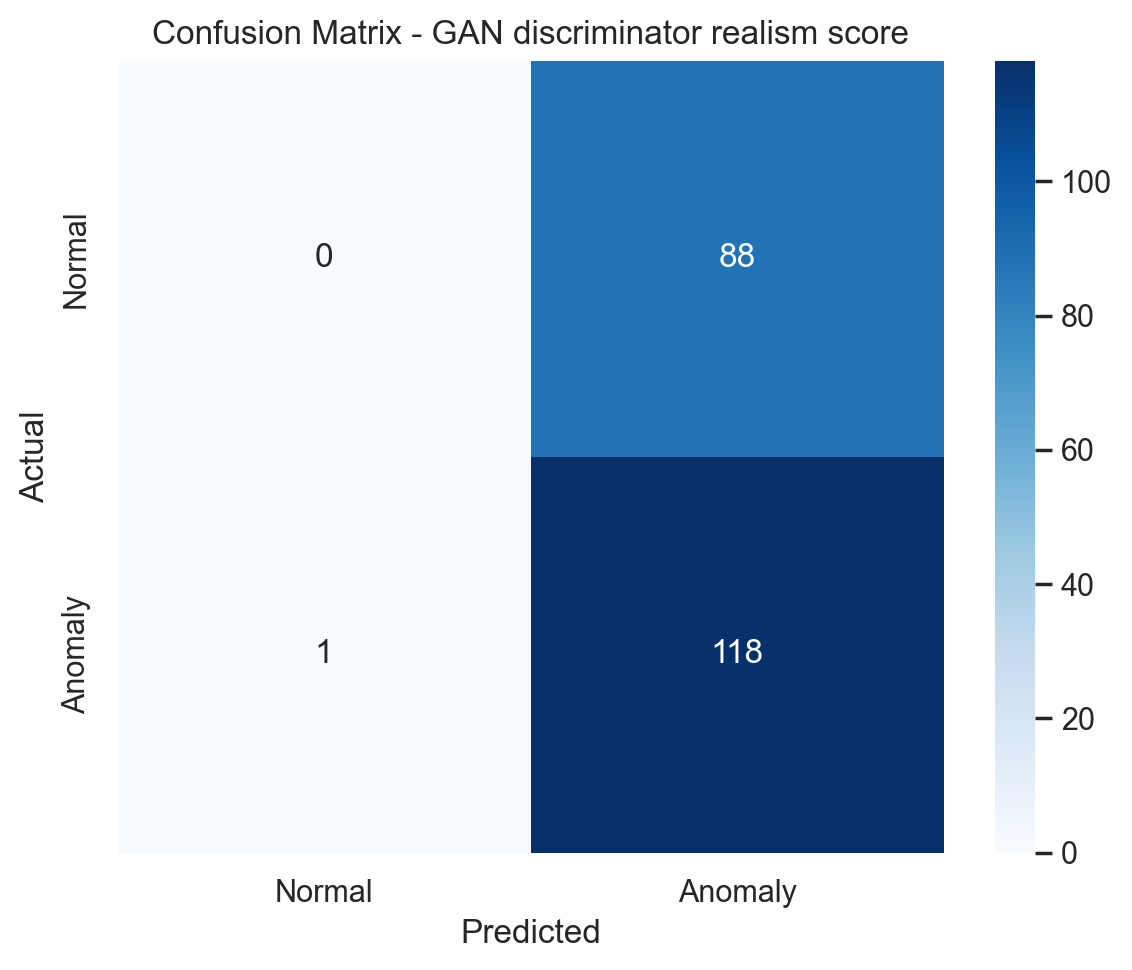

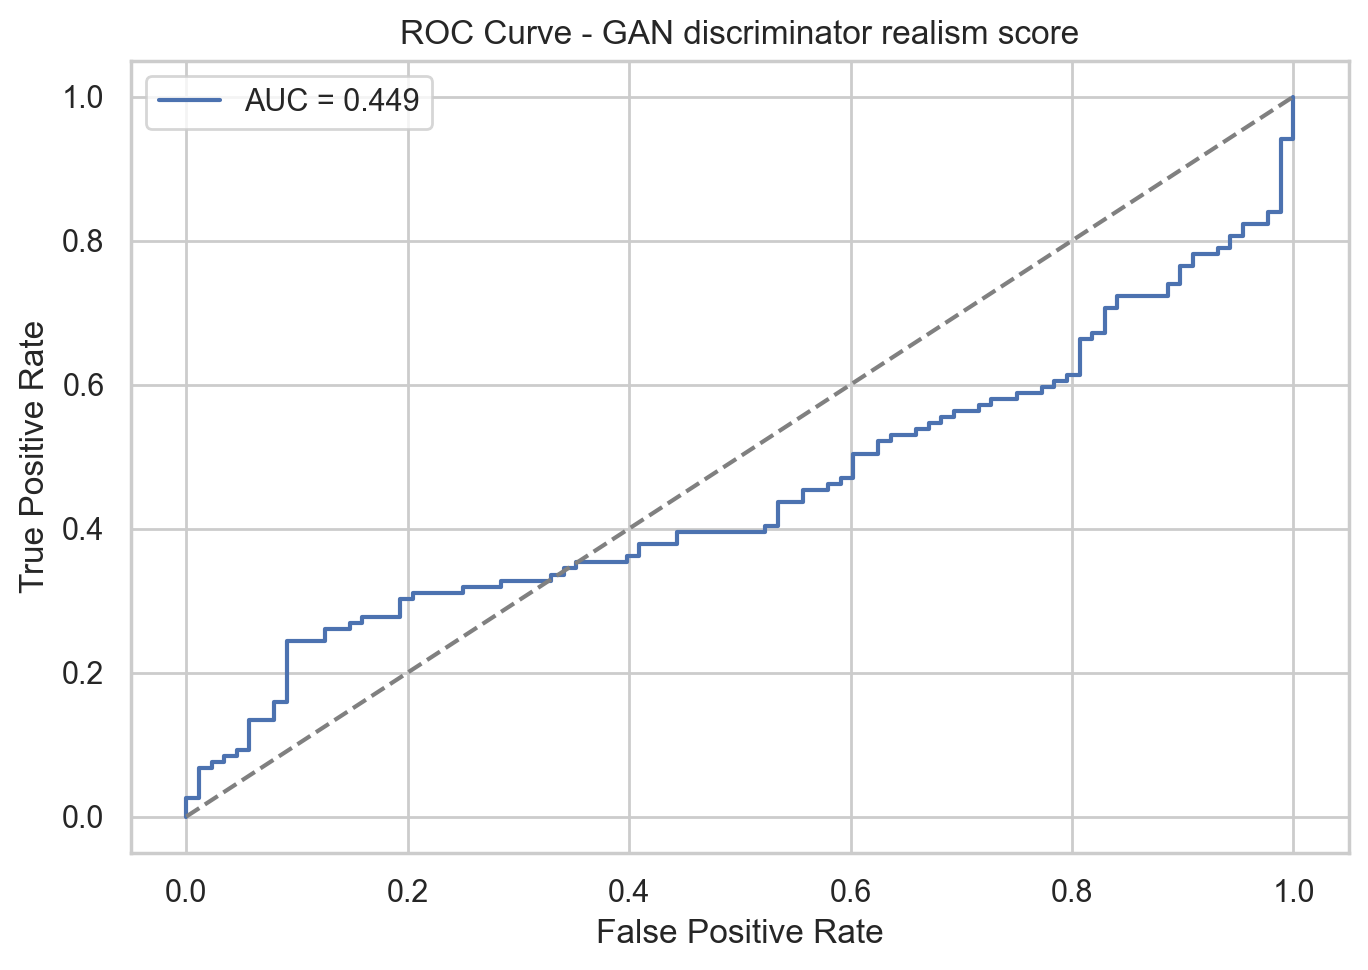


GAN reconstruction score
Precision: 0.6500
Recall:    0.8739
F1 Score:  0.7455
ROC-AUC:   0.7276


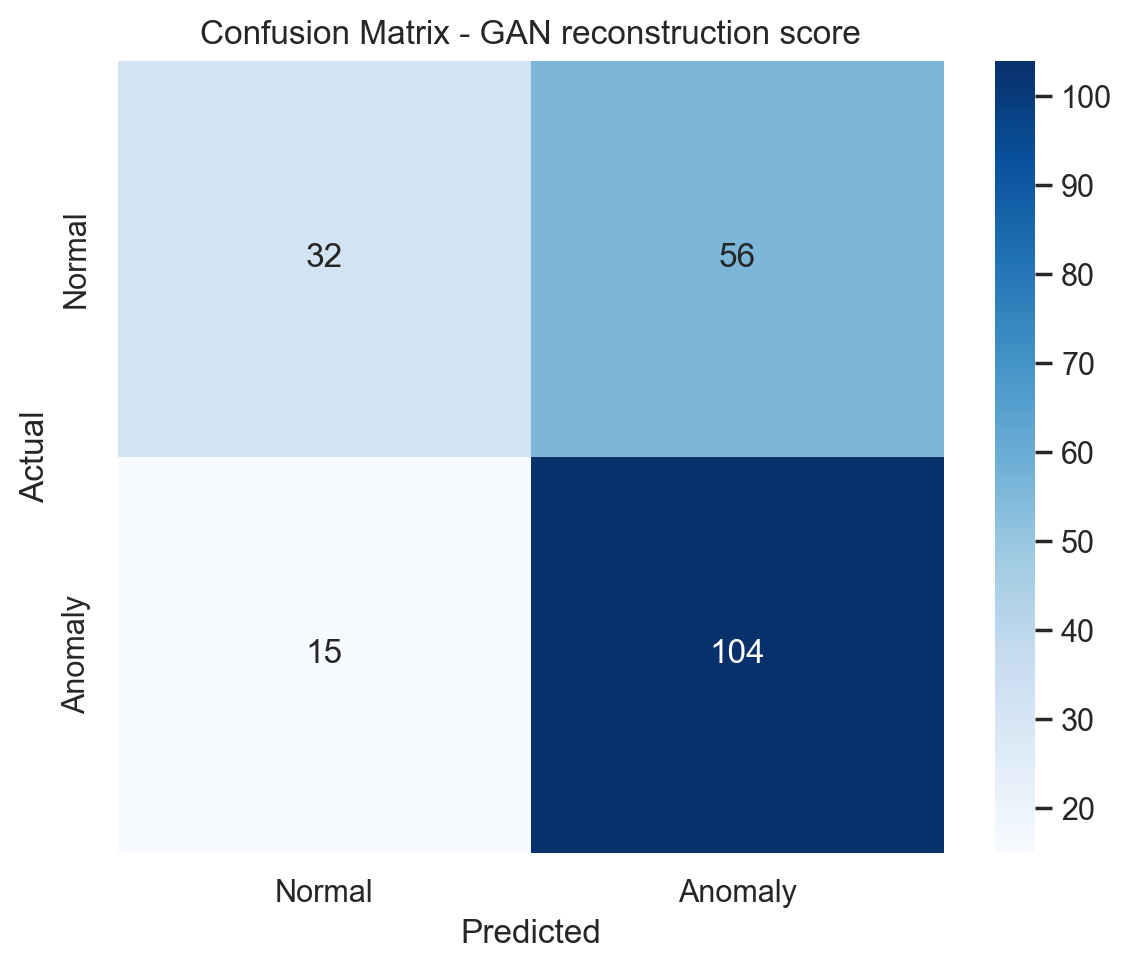

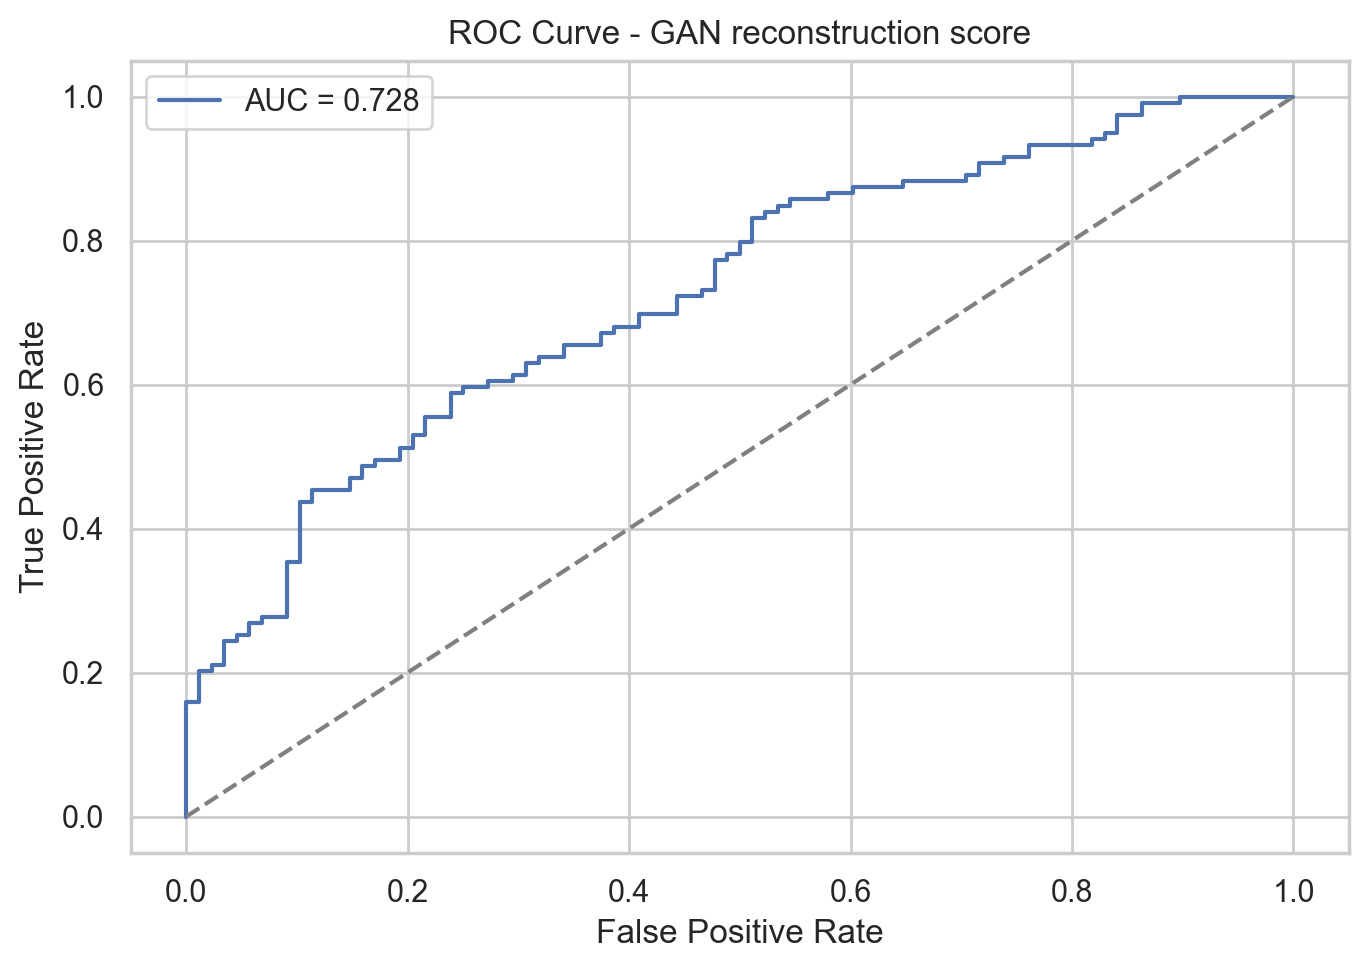

,model,precision,recall,f1,roc_auc
0,GAN discriminator realism score,0.572816,0.991597,0.726154,0.449007
1,GAN reconstruction score,0.650000,0.873950,0.745520,0.727559


In [34]:
def evaluate_anomaly_detector(y_true, y_pred, anomaly_score, model_name):
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    fpr, tpr, _ = roc_curve(y_true, anomaly_score)
    roc_auc = auc(fpr, tpr)

    print(f"\n{model_name}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Anomaly"],
                yticklabels=["Normal", "Anomaly"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        "model": model_name,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
    }

realism_metrics = evaluate_anomaly_detector(
    y_test,
    y_pred_realism,
    1.0 - test_realism,
    "GAN discriminator realism score",
)

reconstruction_metrics = evaluate_anomaly_detector(
    y_test,
    y_pred_reconstruction,
    test_reconstruction_error,
    "GAN reconstruction score",
)

pd.DataFrame([realism_metrics, reconstruction_metrics])

## 7. VAE anomaly detection

A Variational Autoencoder gives a second deep-learning baseline with a different inductive bias from the GAN.

The VAE learns:

- an **encoder** that maps a market observation into a latent Gaussian distribution
- a **decoder** that reconstructs the observation from a sampled latent vector
- a regularized latent space through the KL-divergence term

As with the GAN, the VAE is trained on **normal observations only**. At inference time, observations with high reconstruction error are treated as anomalous:

$$
\text{Anomaly} \Longleftrightarrow \|x - \hat{x}\|^2 > \varepsilon
$$

The threshold is selected on the same cross-validation set used for the GAN scores.

VAE latent dimension: 10
VAE hidden dimension: 84
Epoch 001 | VAE loss=1.0014 | recon=1.0004 | KL=0.0974
Epoch 050 | VAE loss=0.5426 | recon=0.4598 | KL=8.2767
Epoch 100 | VAE loss=0.4811 | recon=0.3723 | KL=10.8802
Epoch 150 | VAE loss=0.4479 | recon=0.3337 | KL=11.4213
Epoch 200 | VAE loss=0.4266 | recon=0.3119 | KL=11.4742
Epoch 250 | VAE loss=0.4069 | recon=0.2860 | KL=12.0863


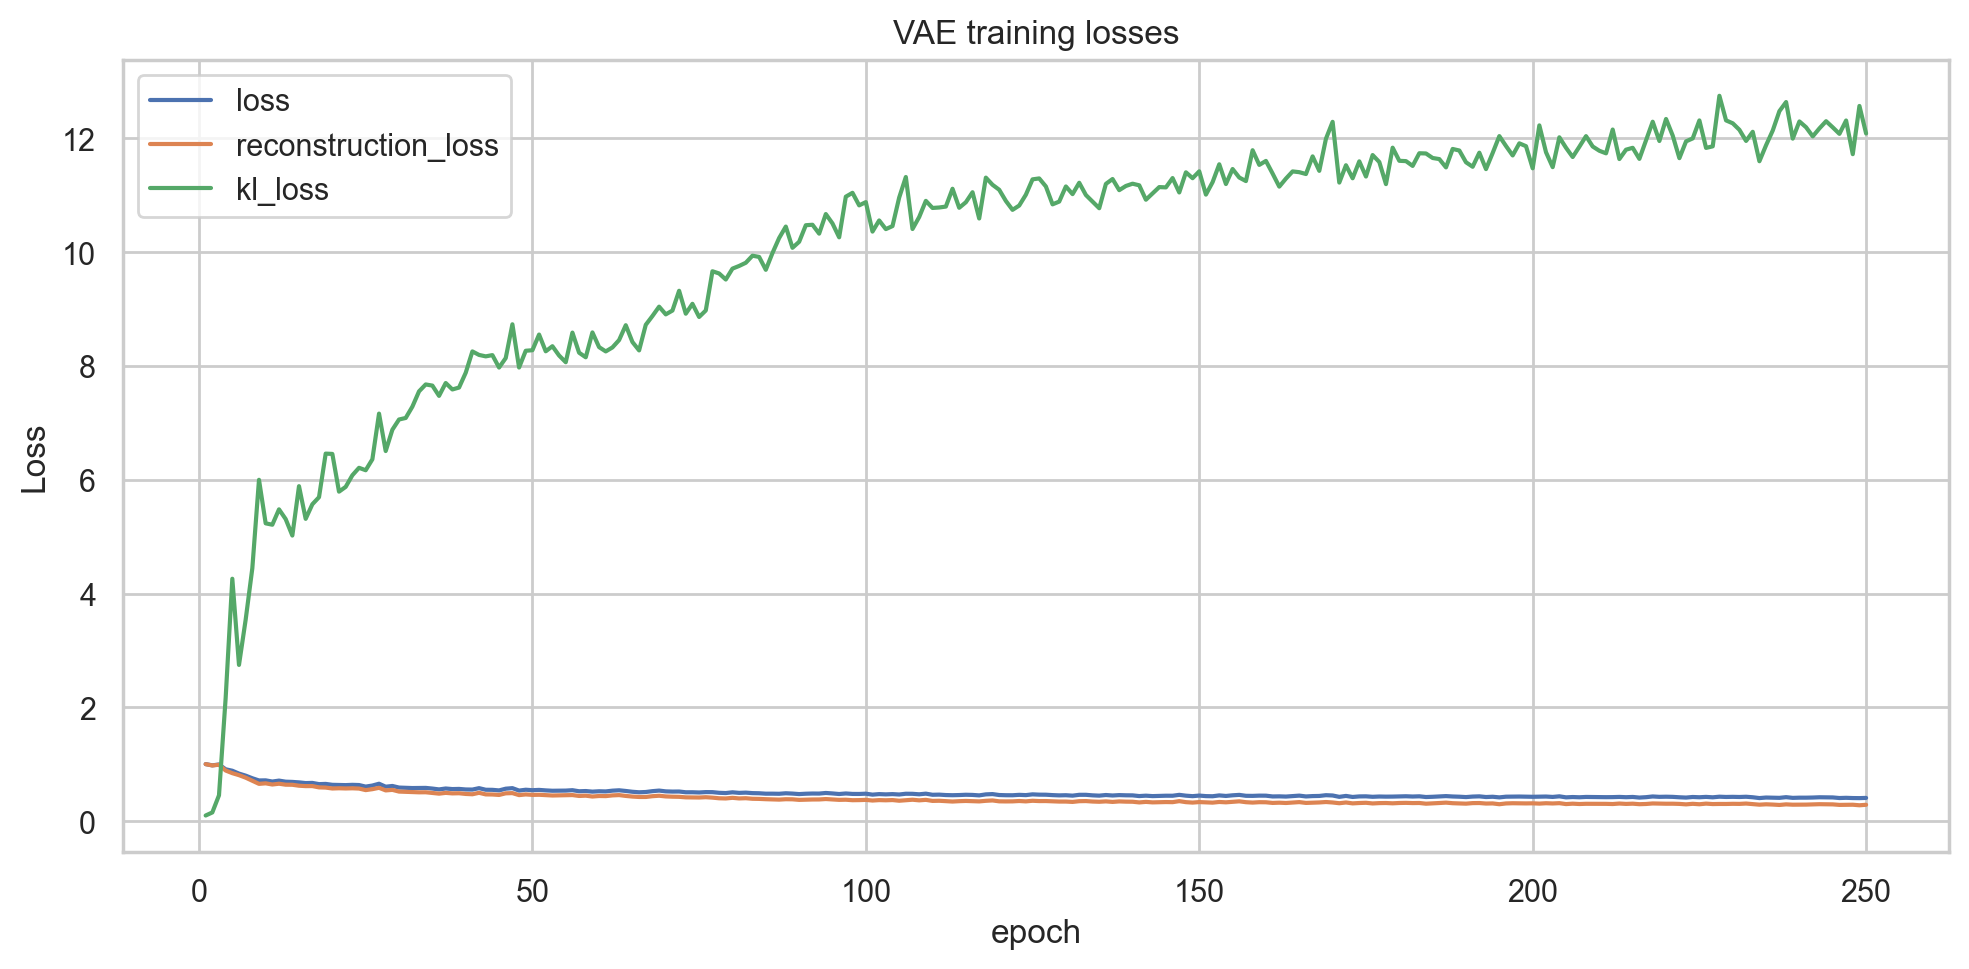


VAE reconstruction score
Precision: 0.6970
Recall:    0.7731
F1 Score:  0.7331
ROC-AUC:   0.7326


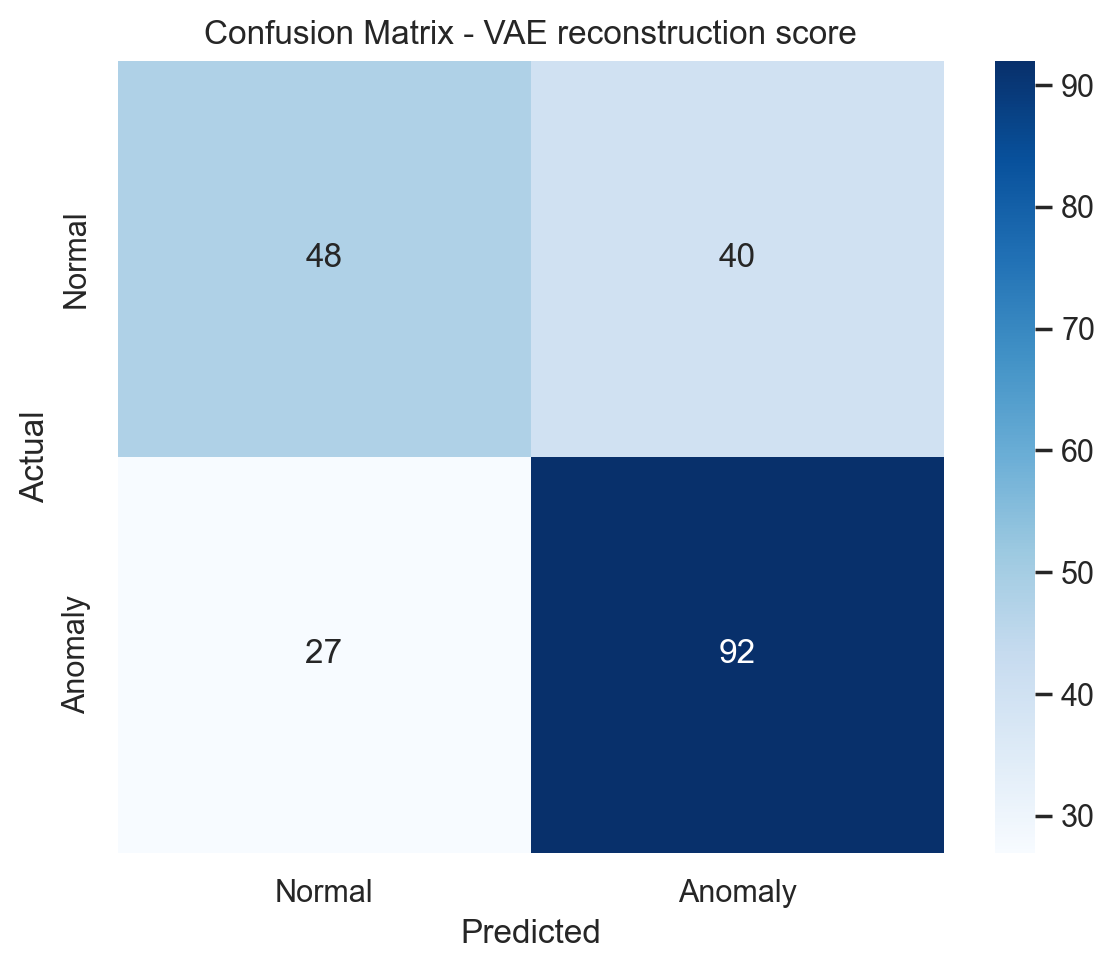

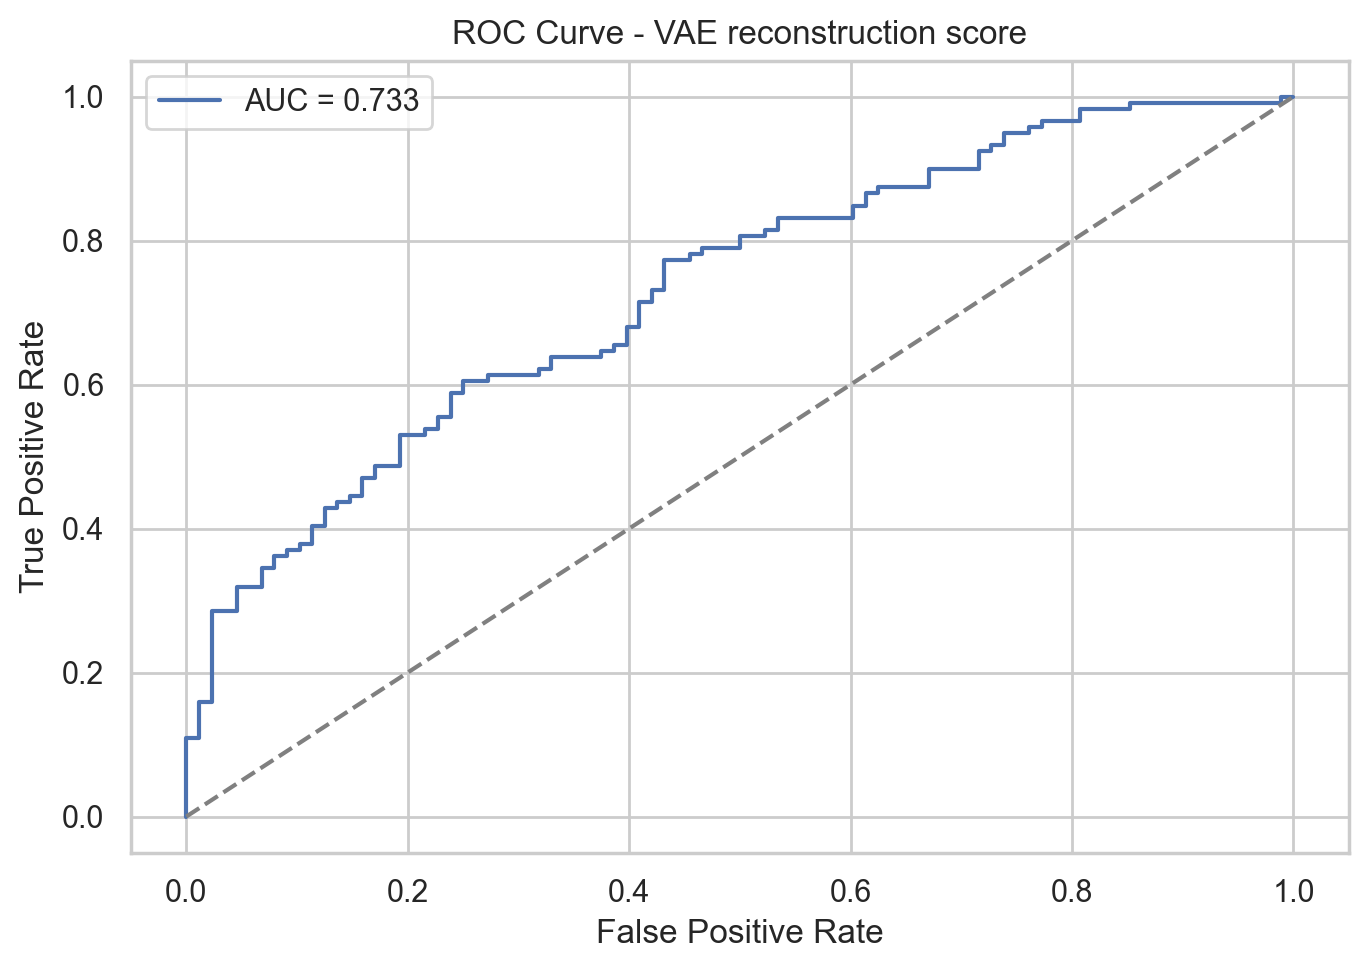

{'epsilon': np.float32(0.30393112),
 'f1': 0.782258064516129,
 'precision': 0.7461538461538462,
 'recall': 0.8220338983050848}

In [35]:
class VAE(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int = 8, hidden_dim: int = 64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.mu_layer = nn.Linear(hidden_dim, latent_dim)
        self.logvar_layer = nn.Linear(hidden_dim, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def encode(self, x):
        hidden = self.encoder(x)
        return self.mu_layer(hidden), self.logvar_layer(hidden)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)
        return reconstruction, mu, logvar


def vae_loss(reconstruction, x, mu, logvar, beta=0.01):
    reconstruction_loss = ((reconstruction - x) ** 2).mean()
    kl_loss = -0.5 * torch.mean(torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))
    return reconstruction_loss + beta * kl_loss, reconstruction_loss, kl_loss


def train_vae(model, loader, epochs=250, beta=0.01, lr=1e-3, patience=30, print_every=50):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    best_loss = float("inf")
    best_state = None
    stale_epochs = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        epoch_reconstruction = 0.0
        epoch_kl = 0.0

        for (batch,) in loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            reconstruction, mu, logvar = model(batch)
            loss, reconstruction_loss, kl_loss = vae_loss(reconstruction, batch, mu, logvar, beta=beta)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            epoch_reconstruction += reconstruction_loss.item()
            epoch_kl += kl_loss.item()

        avg_loss = epoch_loss / len(loader)
        avg_reconstruction = epoch_reconstruction / len(loader)
        avg_kl = epoch_kl / len(loader)
        history.append({
            "epoch": epoch,
            "loss": avg_loss,
            "reconstruction_loss": avg_reconstruction,
            "kl_loss": avg_kl,
        })

        if avg_loss < best_loss:
            best_loss = avg_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            stale_epochs = 0
        else:
            stale_epochs += 1

        if epoch == 1 or epoch % print_every == 0:
            print(
                f"Epoch {epoch:03d} | VAE loss={avg_loss:.4f} | "
                f"recon={avg_reconstruction:.4f} | KL={avg_kl:.4f}"
            )

        if stale_epochs >= patience:
            print(f"Early stopping at epoch {epoch}; best loss={best_loss:.4f}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return pd.DataFrame(history)


def vae_reconstruction_error(model, X):
    model.eval()
    X_tensor = torch.tensor(X, dtype=torch.float32, device=device)
    with torch.no_grad():
        mu, logvar = model.encode(X_tensor)
        reconstruction = model.decode(mu)  # deterministic reconstruction for stable scoring
        errors = ((reconstruction - X_tensor) ** 2).mean(dim=1).cpu().numpy()
    return errors

vae_latent_dim = min(16, max(4, input_dim // 4))
vae_hidden_dim = min(128, max(32, input_dim * 2))
vae_model = VAE(input_dim=input_dim, latent_dim=vae_latent_dim, hidden_dim=vae_hidden_dim).to(device)

print(f"VAE latent dimension: {vae_latent_dim}")
print(f"VAE hidden dimension: {vae_hidden_dim}")

vae_history = train_vae(vae_model, train_loader, epochs=250, beta=0.01, patience=30, print_every=50)

vae_history.plot(x="epoch", y=["loss", "reconstruction_loss", "kl_loss"], figsize=(10, 5))
plt.title("VAE training losses")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

cv_vae_error = vae_reconstruction_error(vae_model, X_cross_val)
test_vae_error = vae_reconstruction_error(vae_model, X_test)

vae_threshold = choose_high_score_threshold(y_cross_val, cv_vae_error)
y_pred_vae = (test_vae_error > vae_threshold["epsilon"]).astype(int)

vae_metrics = evaluate_anomaly_detector(
    y_test,
    y_pred_vae,
    test_vae_error,
    "VAE reconstruction score",
)

vae_threshold

## 8. Compare GAN and VAE anomaly detection

The comparison uses the same train/CV/test split and the same evaluation function for all deep anomaly scores:

- GAN discriminator realism anomaly score: `1 - D_prob(x)`
- GAN reconstruction error
- VAE reconstruction error

This makes the comparison about model behavior rather than about different thresholds, datasets, or metrics.

,model,precision,recall,f1,roc_auc
0,GAN reconstruction score,0.650000,0.873950,0.745520,0.727559
1,VAE reconstruction score,0.696970,0.773109,0.733068,0.732620
2,GAN discriminator realism score,0.572816,0.991597,0.726154,0.449007


/var/folders/qh/7nh8ljpn5m504tw502bjr4880000gn/T/ipykernel_90576/1002495762.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x=metric, y="model", ax=ax, palette="viridis")
/var/folders/qh/7nh8ljpn5m504tw502bjr4880000gn/T/ipykernel_90576/1002495762.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x=metric, y="model", ax=ax, palette="viridis")
/var/folders/qh/7nh8ljpn5m504tw502bjr4880000gn/T/ipykernel_90576/1002495762.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x=metric,

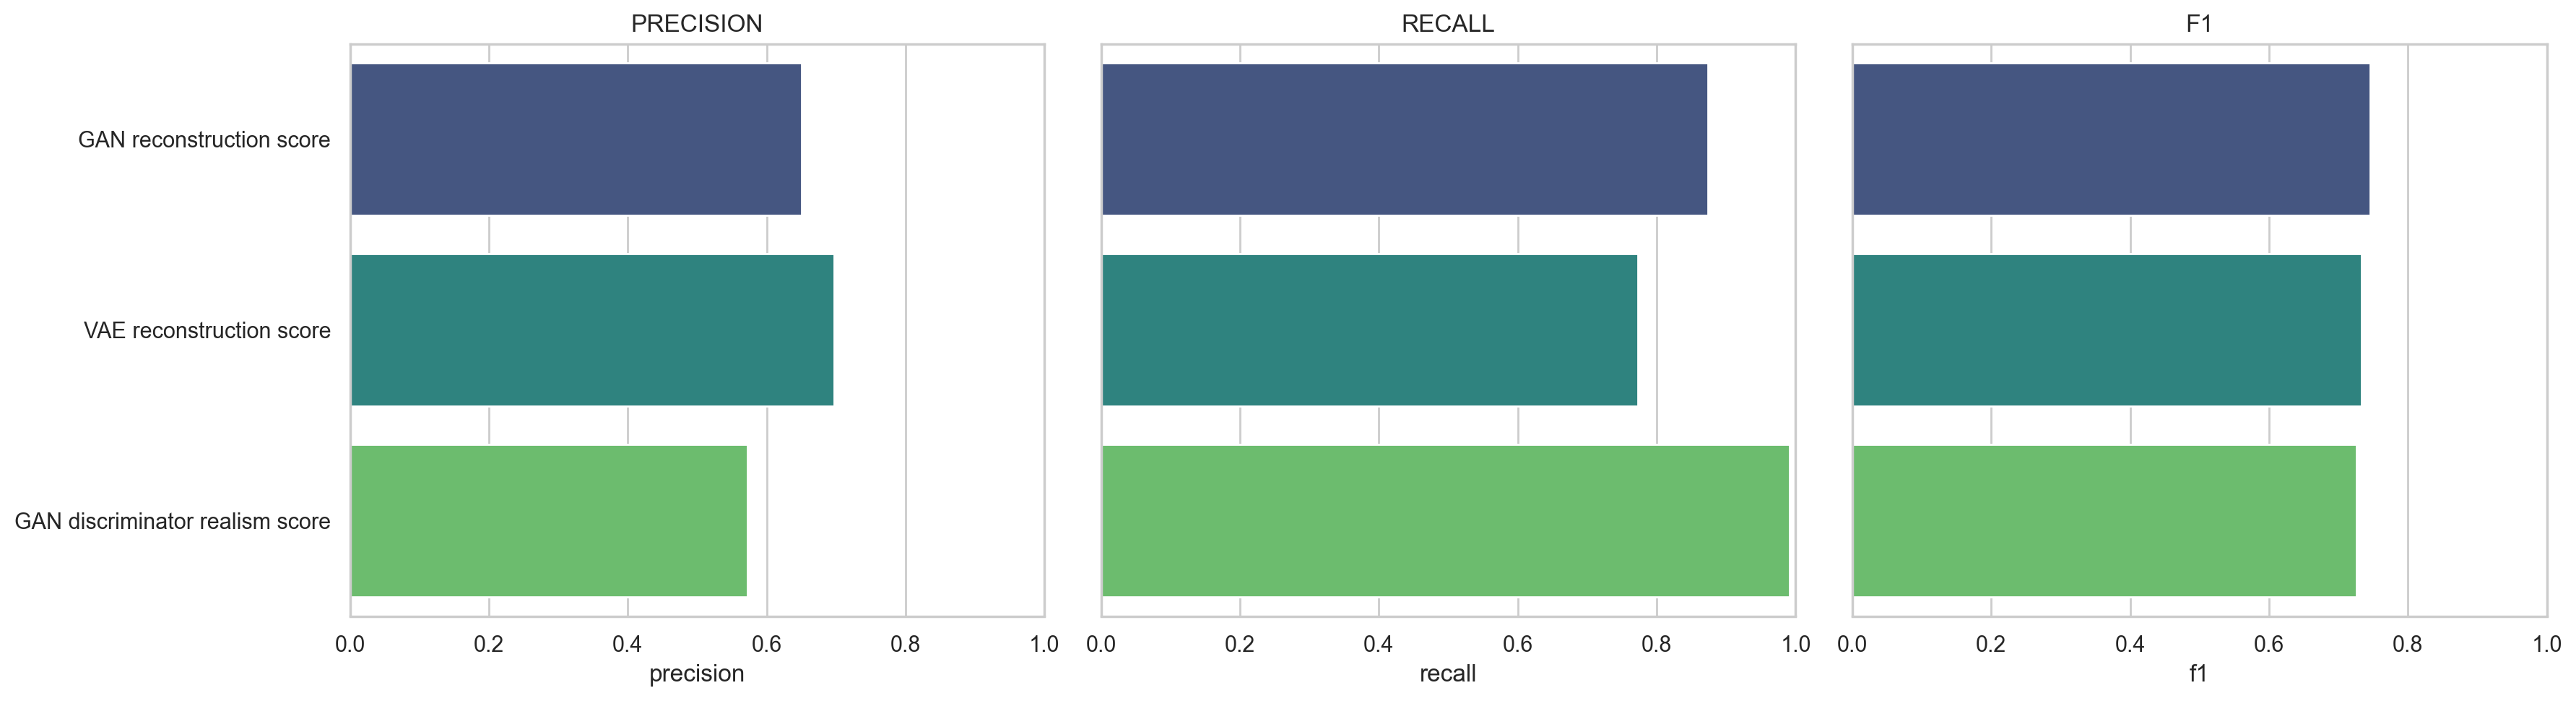

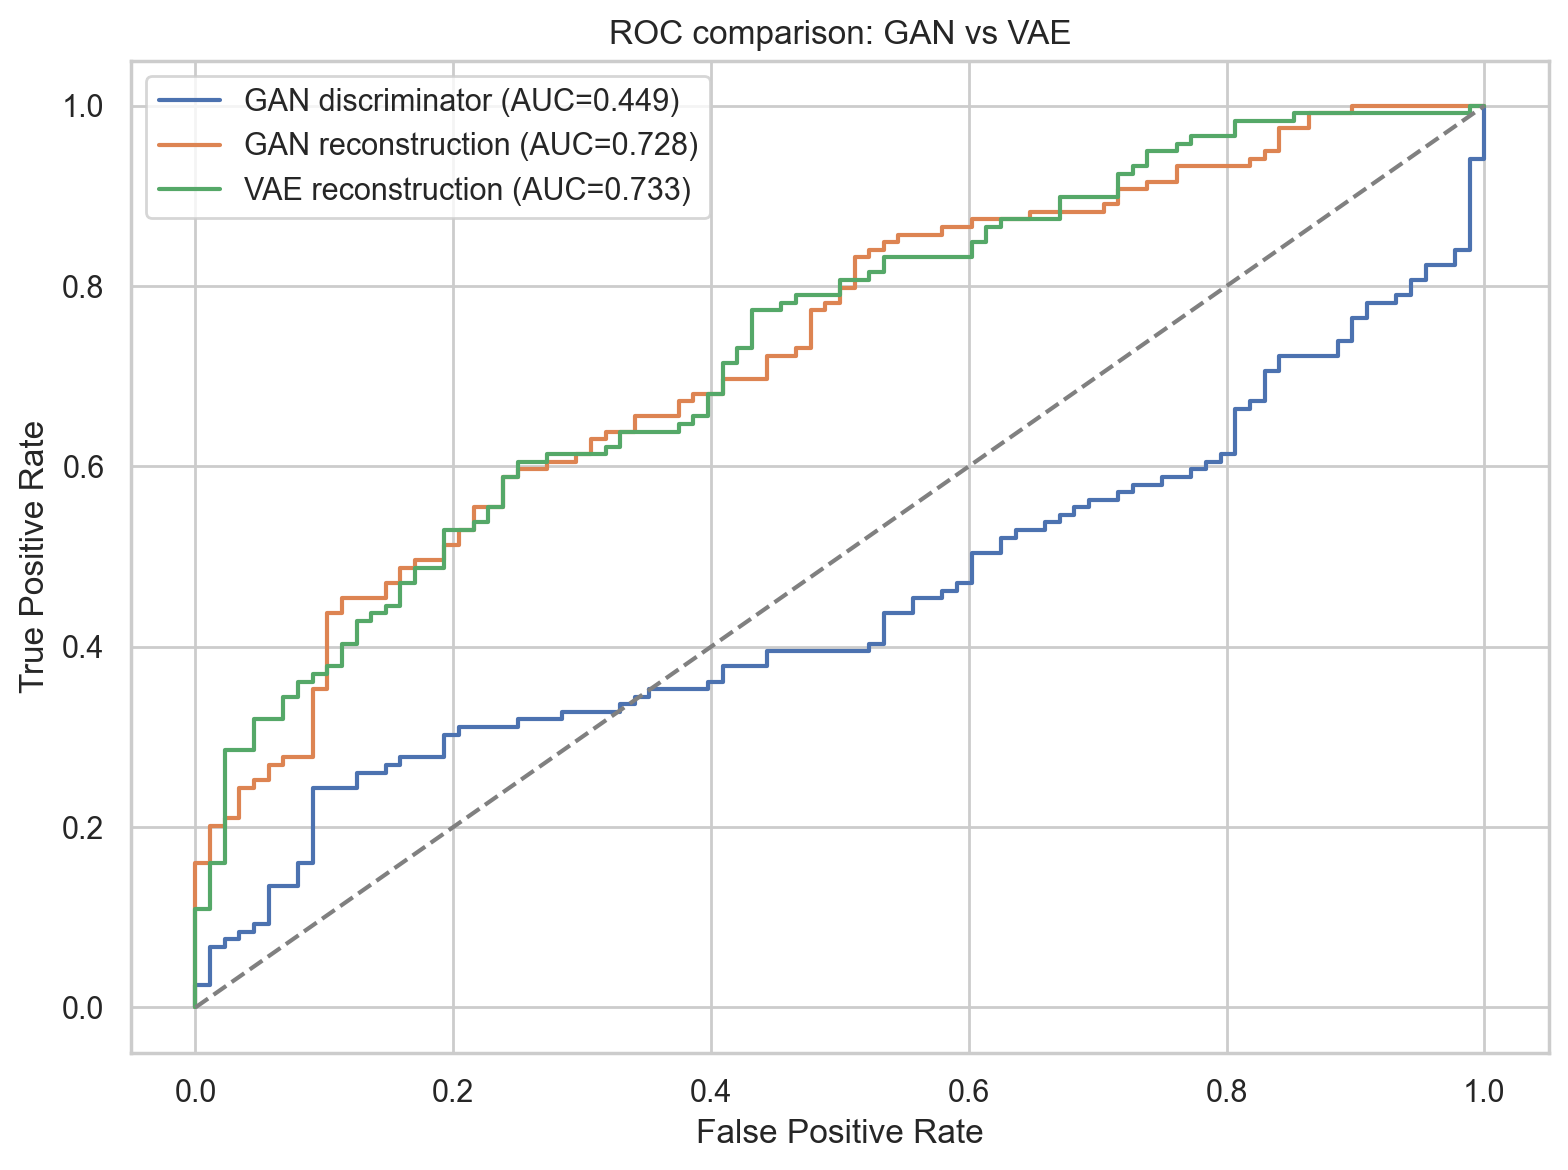

In [36]:
comparison_df = pd.DataFrame([realism_metrics, reconstruction_metrics, vae_metrics])
comparison_df = comparison_df.sort_values("f1", ascending=False).reset_index(drop=True)
display(comparison_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
metrics_to_plot = ["precision", "recall", "f1"]
for ax, metric in zip(axes, metrics_to_plot):
    sns.barplot(data=comparison_df, x=metric, y="model", ax=ax, palette="viridis")
    ax.set_xlim(0, 1)
    ax.set_title(metric.upper())
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
for label, score in [
    ("GAN discriminator", 1.0 - test_realism),
    ("GAN reconstruction", test_reconstruction_error),
    ("VAE reconstruction", test_vae_error),
]:
    fpr, tpr, _ = roc_curve(y_test, score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC comparison: GAN vs VAE")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Visual diagnostics

The score distribution shows whether anomalies are separated from normal observations. Because the real market dataset has many features, we use PCA to project the standardized test set into two dimensions for a qualitative view of both GAN and VAE reconstruction-based decisions.

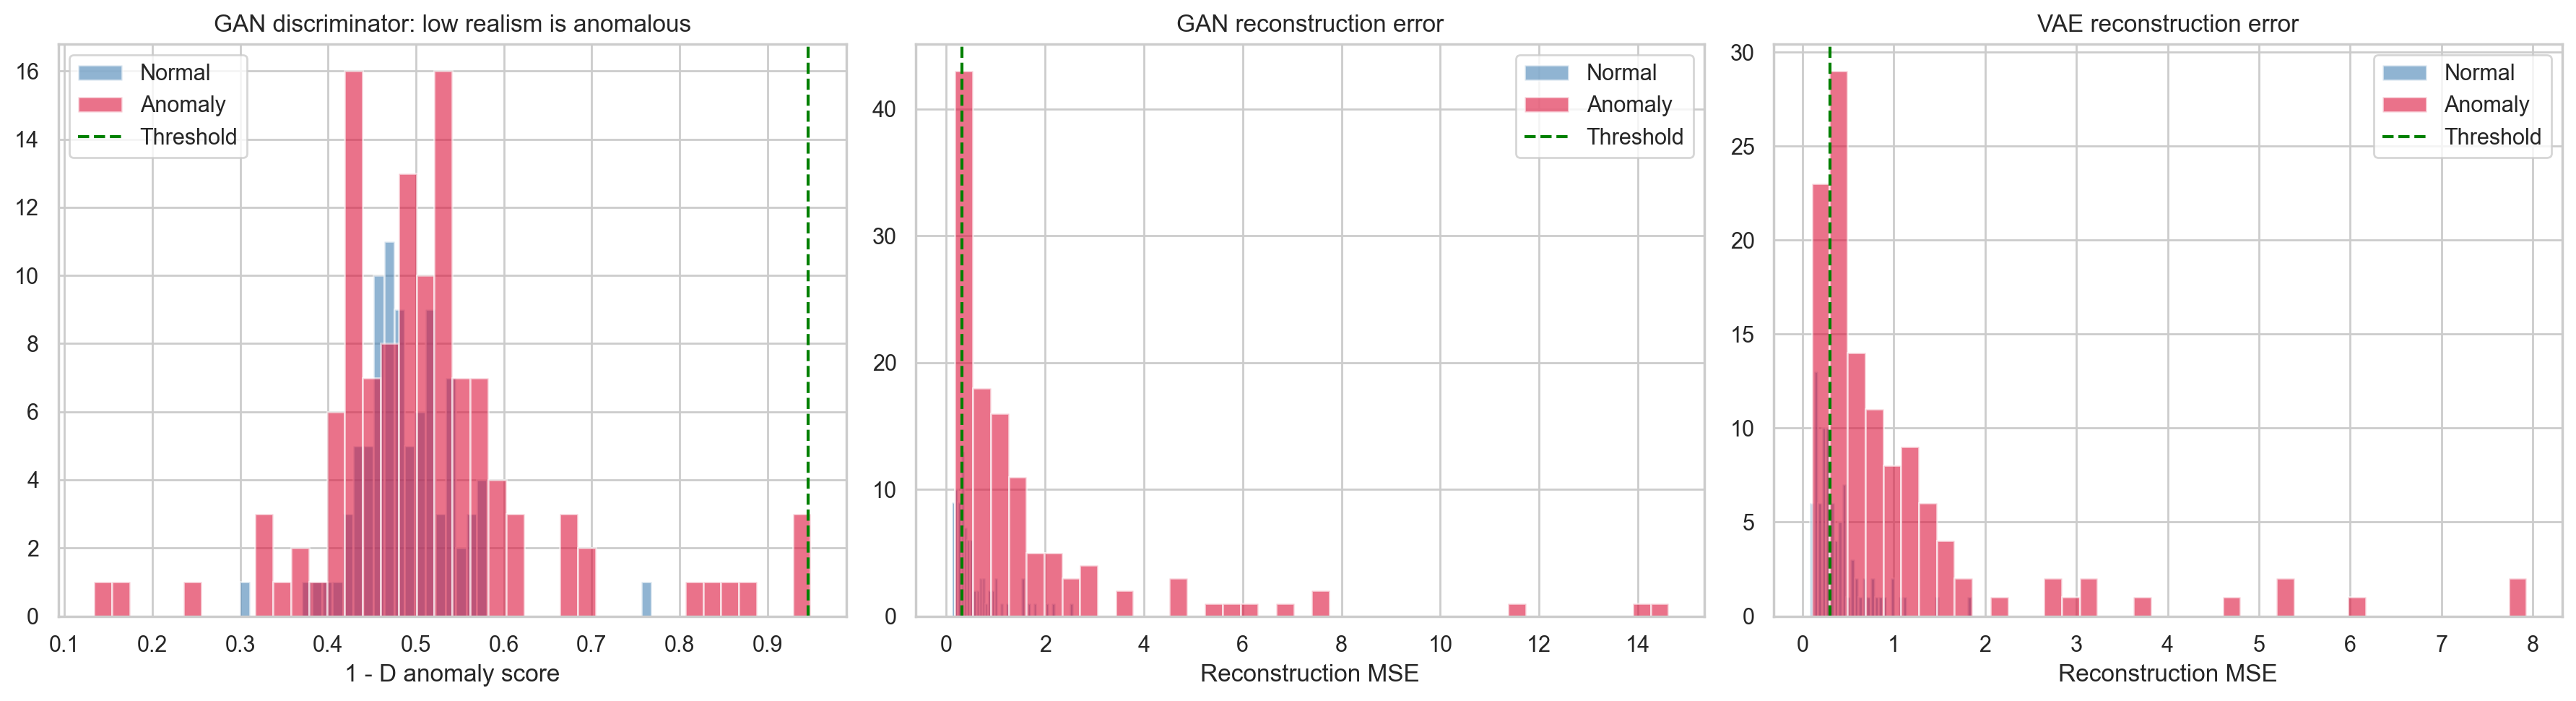

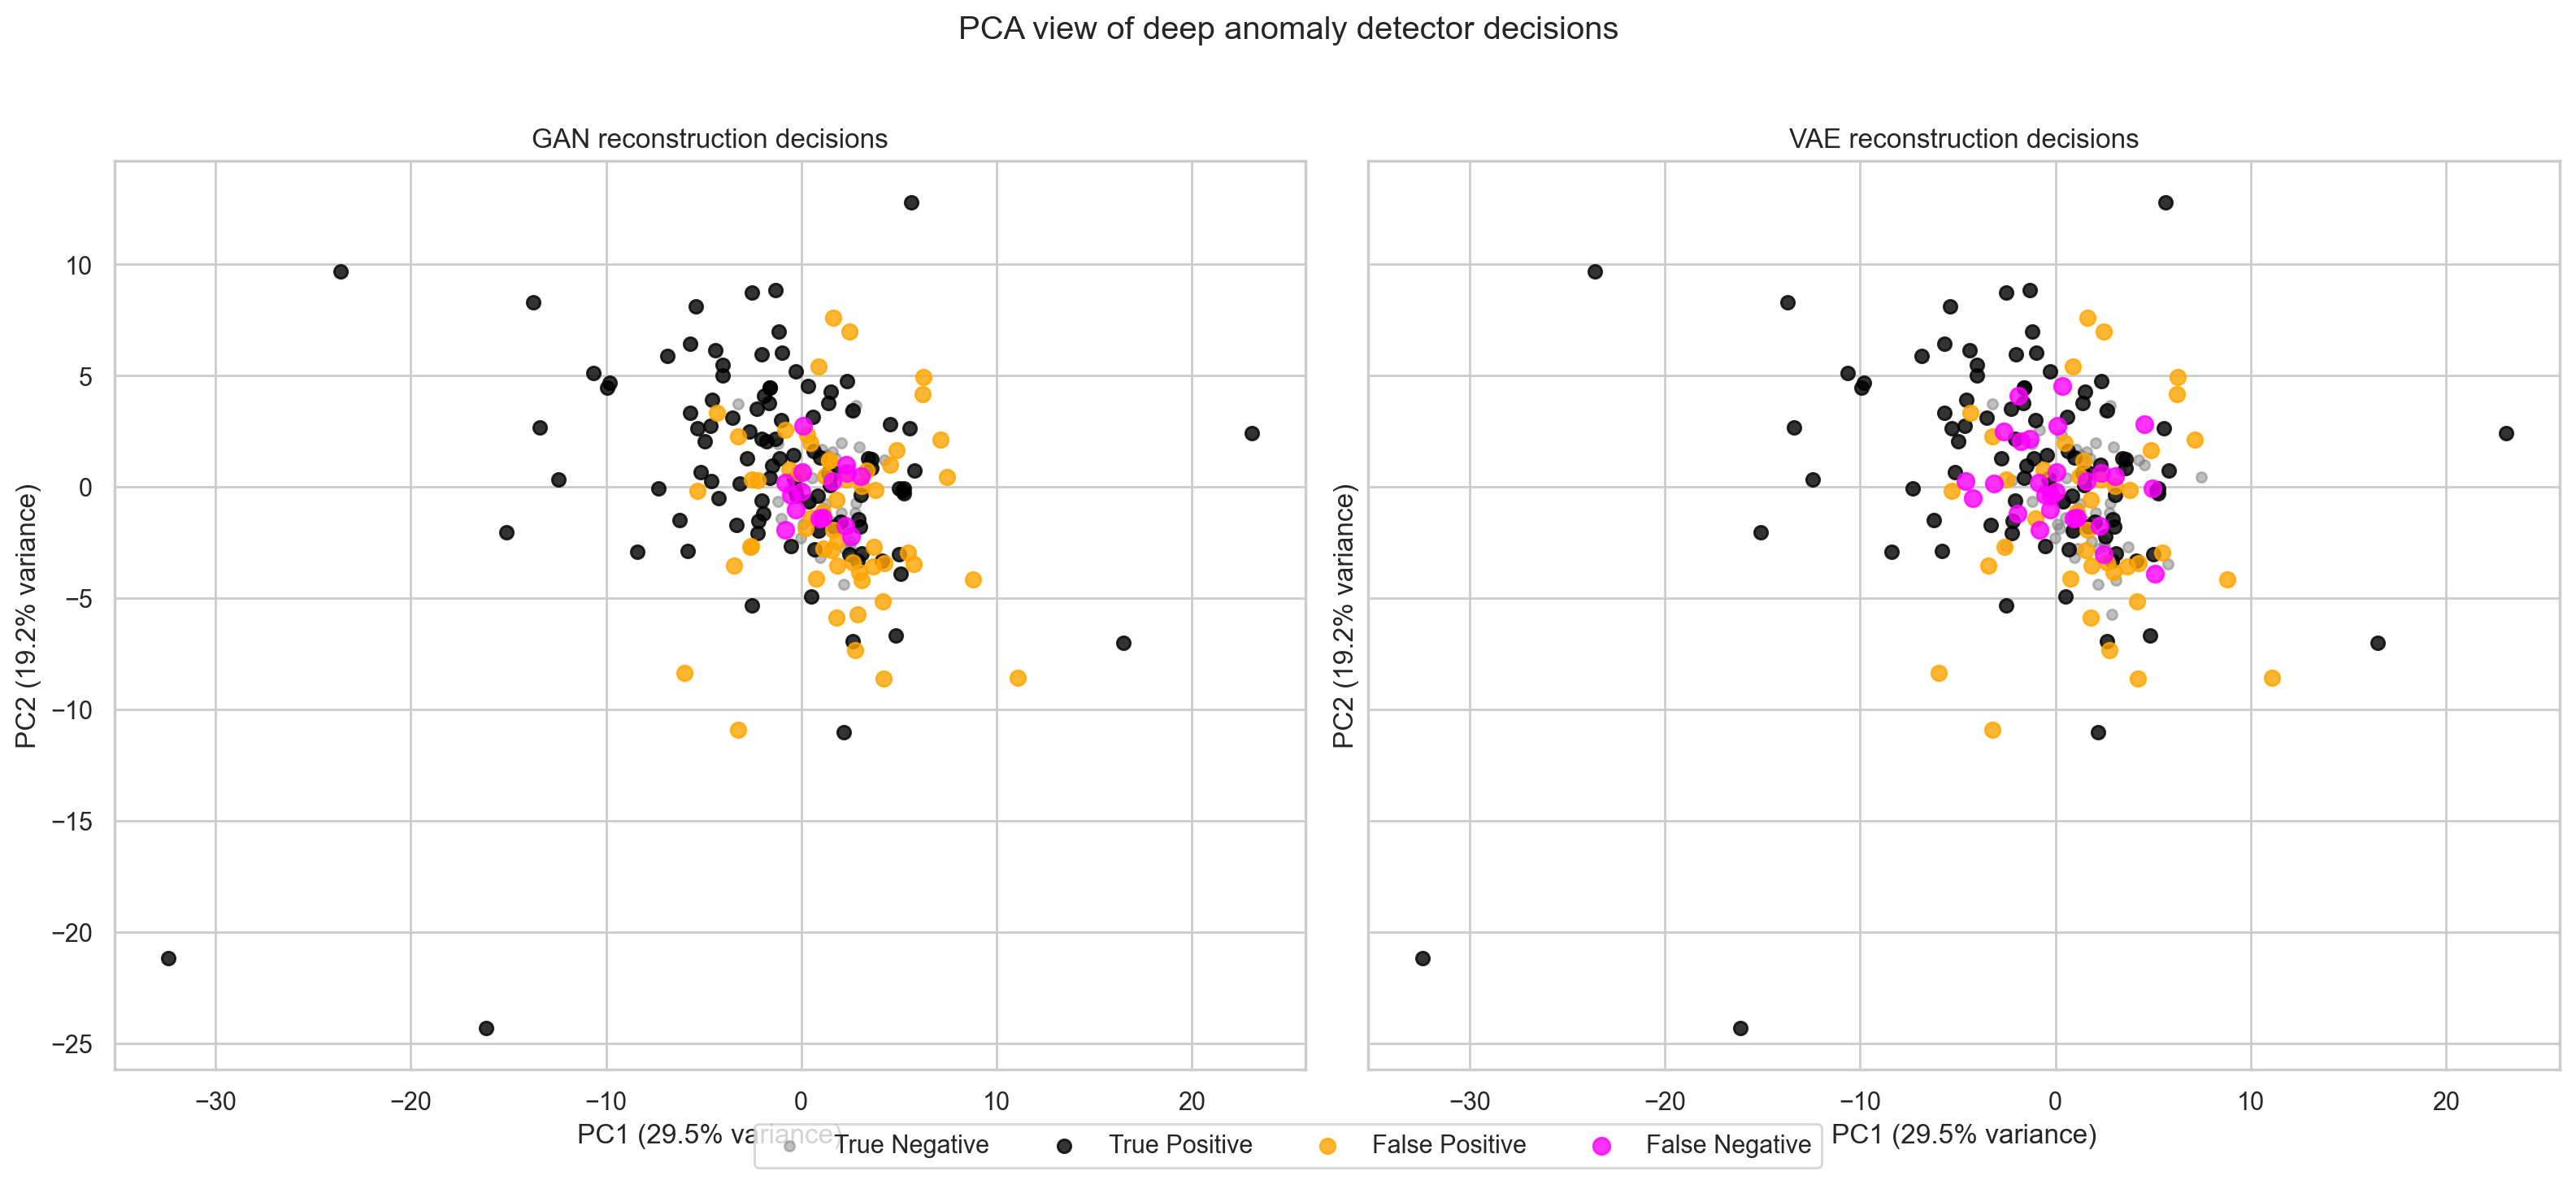

,Mean absolute standardized train value
ECSURPUS,0.796640
DXY,0.792875
XAUBGNL,0.786672
JPY,0.784774
CRY,0.783883
USGG30YR,0.776961
MXBR,0.774196
GTDEM10Y,0.768674
MXCN,0.765876
GT10,0.764885


In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(test_realism[y_test == 0], bins=40, alpha=0.6, label="Normal", color="steelblue")
axes[0].hist(test_realism[y_test == 1], bins=40, alpha=0.6, label="Anomaly", color="crimson")
axes[0].axvline(realism_threshold["epsilon"], color="green", linestyle="--", label="Threshold")
axes[0].set_title("GAN discriminator: low realism is anomalous")
axes[0].set_xlabel("1 - D anomaly score")
axes[0].legend()

axes[1].hist(test_reconstruction_error[y_test == 0], bins=40, alpha=0.6, label="Normal", color="steelblue")
axes[1].hist(test_reconstruction_error[y_test == 1], bins=40, alpha=0.6, label="Anomaly", color="crimson")
axes[1].axvline(reconstruction_threshold["epsilon"], color="green", linestyle="--", label="Threshold")
axes[1].set_title("GAN reconstruction error")
axes[1].set_xlabel("Reconstruction MSE")
axes[1].legend()

axes[2].hist(test_vae_error[y_test == 0], bins=40, alpha=0.6, label="Normal", color="steelblue")
axes[2].hist(test_vae_error[y_test == 1], bins=40, alpha=0.6, label="Anomaly", color="crimson")
axes[2].axvline(vae_threshold["epsilon"], color="green", linestyle="--", label="Threshold")
axes[2].set_title("VAE reconstruction error")
axes[2].set_xlabel("Reconstruction MSE")
axes[2].legend()

plt.tight_layout()
plt.show()

pca = PCA(n_components=2, random_state=SEED)
X_test_pca = pca.fit_transform(X_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

def plot_pca_decisions(ax, y_pred, title):
    ax.scatter(X_test_pca[(y_test == 0) & (y_pred == 0), 0],
               X_test_pca[(y_test == 0) & (y_pred == 0), 1],
               c="gray", s=20, alpha=0.5, label="True Negative")
    ax.scatter(X_test_pca[(y_test == 1) & (y_pred == 1), 0],
               X_test_pca[(y_test == 1) & (y_pred == 1), 1],
               c="black", s=35, alpha=0.8, label="True Positive")
    ax.scatter(X_test_pca[(y_test == 0) & (y_pred == 1), 0],
               X_test_pca[(y_test == 0) & (y_pred == 1), 1],
               c="orange", s=45, alpha=0.8, label="False Positive")
    ax.scatter(X_test_pca[(y_test == 1) & (y_pred == 0), 0],
               X_test_pca[(y_test == 1) & (y_pred == 0), 1],
               c="magenta", s=55, alpha=0.8, label="False Negative")
    ax.set_title(title)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")

plot_pca_decisions(axes[0], y_pred_reconstruction, "GAN reconstruction decisions")
plot_pca_decisions(axes[1], y_pred_vae, "VAE reconstruction decisions")
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4)
fig.suptitle("PCA view of deep anomaly detector decisions", y=1.02)
plt.tight_layout()
plt.show()

feature_summary = pd.Series(np.abs(X_train).mean(axis=0), index=feature_names).sort_values(ascending=False)
feature_summary.head(10).to_frame("Mean absolute standardized train value")

## 10. Notes and next steps

This notebook now trains and evaluates both GAN and VAE anomaly detectors directly on the real BC4 EWS market dataset.

Keep the interpretation conservative:

1. Both models are trained only on normal market observations, so they are novelty detectors rather than crisis classifiers.
2. The GAN discriminator realism score, GAN reconstruction score, and VAE reconstruction score are different views of compatibility with learned normality.
3. The threshold is tuned on the labeled cross-validation set, matching the logic of the original MVG and Autoencoder sections.
4. The comparison table and ROC plot should be interpreted alongside simpler baselines in `EarlyWarningSystemPoliMI.ipynb`.

Practical warning: GANs and VAEs can both be unstable on tabular financial data. Rerun with several seeds and compare score distributions before trusting any single training run.